## New York Taxi Trip Duration Regression

### Imports

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

### Loading Dataset

In [185]:
df = pd.read_csv("data/NYC.csv")

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [186]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


### Handling Null Values, Duplicates and unncessairy columns

In [187]:
print(df.isnull().sum())
print(df.duplicated().sum())

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64
0


In [188]:
## id is irrelevant for the model
## dropoff_datetime to prevent data leakage
df.drop(columns=["dropoff_datetime", "id"], inplace=True)

### Date Feature Engineering

In [189]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek
df["pickup_month"] = df["pickup_datetime"].dt.month
df["is_weekend"] = df["pickup_dayofweek"] >= 5

In [190]:
df[[
    "pickup_datetime",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend"
]].head()

,pickup_datetime,pickup_hour,pickup_dayofweek,pickup_month,is_weekend
0,2016-03-14 17:24:55,17,0,3,False
1,2016-06-12 00:43:35,0,6,6,True
2,2016-01-19 11:35:24,11,1,1,False
3,2016-04-06 19:32:31,19,2,4,False
4,2016-03-26 13:30:55,13,5,3,True


In [191]:
df = df.drop(columns=["pickup_datetime"])

In [192]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1458644 non-null  int64  
 1   passenger_count     1458644 non-null  int64  
 2   pickup_longitude    1458644 non-null  float64
 3   pickup_latitude     1458644 non-null  float64
 4   dropoff_longitude   1458644 non-null  float64
 5   dropoff_latitude    1458644 non-null  float64
 6   store_and_fwd_flag  1458644 non-null  str    
 7   trip_duration       1458644 non-null  int64  
 8   pickup_hour         1458644 non-null  int32  
 9   pickup_dayofweek    1458644 non-null  int32  
 10  pickup_month        1458644 non-null  int32  
 11  is_weekend          1458644 non-null  bool   
dtypes: bool(1), float64(4), int32(3), int64(3), str(1)
memory usage: 107.1 MB


In [193]:
df['trip_duration'].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

In [194]:
df.sort_values(by='trip_duration', ascending=False).head(10)

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,is_weekend
978383,1,1,-73.783905,40.648632,-73.978271,40.750202,N,3526282,22,5,2,True
924150,1,1,-73.983788,40.742325,-73.985489,40.727676,N,2227612,6,1,1,False
680594,1,2,-73.921677,40.735252,-73.984749,40.759979,N,2049578,22,5,2,True
355003,1,1,-73.789650,40.643559,-73.956810,40.773087,N,1939736,0,1,1,False
1234291,2,2,-73.794525,40.644825,-73.991051,40.755573,N,86392,23,0,2,False
295382,2,1,-73.781952,40.644688,-73.993874,40.745926,N,86391,13,1,5,False
73816,2,1,-73.996010,40.753220,-73.979027,40.740601,N,86390,0,4,5,False
59891,2,1,-73.992279,40.749729,-73.962524,40.800770,N,86387,16,3,6,False
1360439,2,1,-73.782089,40.644806,-73.985016,40.666828,N,86385,16,3,6,False
753765,2,4,-74.006111,40.734680,-73.958809,40.815449,N,86379,22,1,5,False


In [195]:
Q1 = df["trip_duration"].quantile(0.25)
Q3 = df["trip_duration"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

max_non_outlier = df.loc[
    df["trip_duration"] <= upper_bound,
    "trip_duration"
].max()

print("Upper bound:", upper_bound)
print("Maximum non-outlier:", max_non_outlier)

Upper bound: 2092.0
Maximum non-outlier: 2092


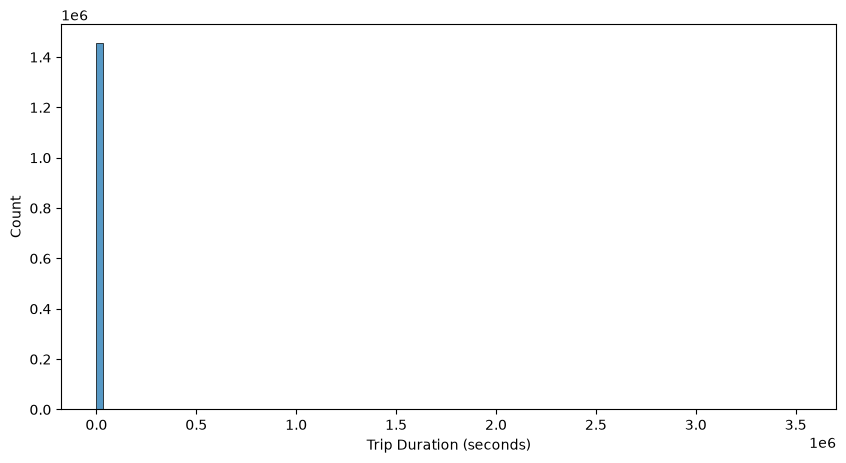

In [196]:
plt.figure(figsize=(10, 5))
sns.histplot(df["trip_duration"], bins=100)
plt.xlabel("Trip Duration (seconds)")
plt.show()

In [197]:
print(
    len(df[df["trip_duration"] > 4000]) / len(df) * 100
)

0.5686102983318754


In [198]:
df =df[df["trip_duration"] <= 4000]

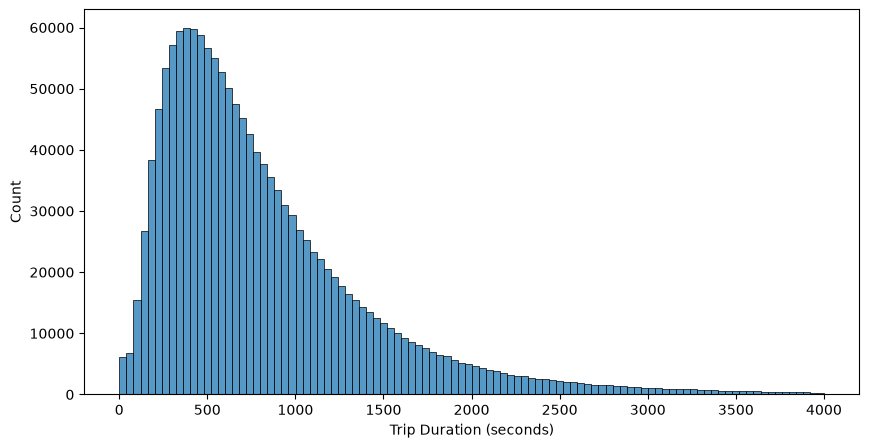

In [199]:
plt.figure(figsize=(10, 5))
sns.histplot(df["trip_duration"], bins=100)
plt.xlabel("Trip Duration (seconds)")
plt.show()